In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 16,          # base font size
    "axes.labelsize": 18,     # x and y labels
    "axes.titlesize": 18,     # title
    "legend.fontsize": 14,    # legend
    "xtick.labelsize": 14,    # x tick labels
    "ytick.labelsize": 14,    # y tick labels
})

import sys
import os
import copy

sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code")) 

In [10]:
from halo_model.halos.base.mass_converter import NFWMassConverter
from halo_model.config.config import Config
from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.r_vir.models.SO import R_virSO
from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.profile.models.stellar_truncated_powerlaw import ProfileStellarTruncatedPowerLaw
from halo_model.halos.base.profile.models.gas_cored_powerlaw import ProfileGasCoredPowerLaw

from halo_model.halos.base.shmr.models.moster2013 import SHMRMoster2013
from halo_model.halos.base.shmr.models.moster2013_centrals import SHMRMoster2013Centrals

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import romb

from halo_model.algorithms.downhill_simplex import downhill_simplex
from halo_model.algorithms.fourier import fourier

sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code/plotting_code/gas_profile")) 

cfg = Config()

In [11]:
R_vir = R_virSO(cfg)
cfg500 = copy.deepcopy(cfg)
cfg500.massdef = '500c'
R500c = R_virSO(cfg500)

c = ConcentrationNeto2007(cfg)

shmr = SHMRMoster2013(cfg, c)
shmr_central = SHMRMoster2013Centrals(cfg, c)

dmprofile = ProfileNFW(c, R_vir)
gasprofile = ProfileGasCoredPowerLaw(cfg, shmr, c)

stellar_profile = ProfileStellarTruncatedPowerLaw(cfg, c)

Computing Fourier transform of gas profile...
Computing Fourier transform of stellar profile...


KeyboardInterrupt: 

128
r_vir: 0.03503647156014282
r_vir: 0.1626248951627506
r_vir: 0.754837897454872


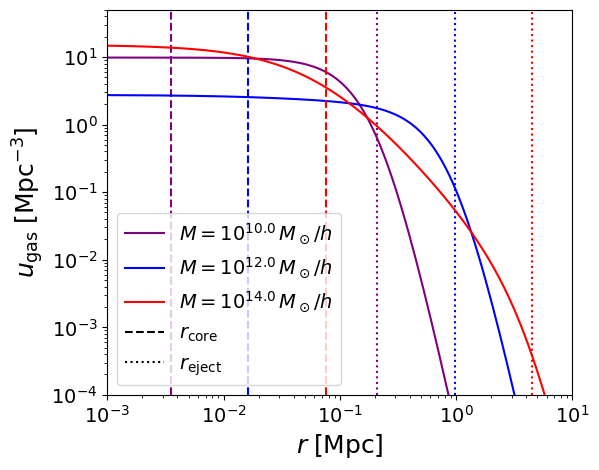

In [ ]:
cfg.massdef = "200c"

z = 0
rmin, rmax = 1e-3, 10
Nr = 2**7
print(Nr)
r_grid = np.geomspace(rmin, rmax, Nr + 1)

plt.figure(figsize=(6,5))
for M, color in zip([1e10, 1e12, 1e14], ['purple', 'blue', 'red']):
    r_vir = R_virSO(cfg).R_vir(cfg.cosmo, M, z)
    print("r_vir:", r_vir)

    rho_gas_grid = gasprofile.real(cfg.cosmo, r_grid, M, z)
    normalization = romb(r_grid*rho_gas_grid, np.log(r_grid[1]) - np.log(r_grid[0]))    
    rho_gas_grid = rho_gas_grid/normalization
    
    plt.plot(
        r_grid,
        rho_gas_grid,
        label=rf"$M = 10^{{{np.log10(M):.1f}}}\,M_\odot/h$",
        color = color
    )
    r_core = 0.1*r_vir
    r_eject = 6*r_vir
    plt.vlines(r_core, ymin=1e-4, ymax=5e1, linestyle='--', color=color)
    plt.vlines(r_eject, ymin=1e-4, ymax=5e1, linestyle=':', color=color)
    
plt.plot([], [], 'k--', label=r"$r_\mathrm{core}$")
plt.plot([], [], 'k:',  label=r"$r_\mathrm{eject}$")    

plt.xscale("log")
plt.xlim(rmin, rmax)
plt.ylim(1e-4, 5e1)
plt.yscale("log")
plt.ylabel(r"$u_\mathrm{gas} \; [\mathrm{Mpc}^{-3}]$")
plt.xlabel(r"$r  \; [\mathrm{Mpc}]$")
plt.legend(loc="lower left")
plt.savefig("normalized_gas_profile_real_space_mass_comparison.pdf",
            bbox_inches="tight")
plt.show()

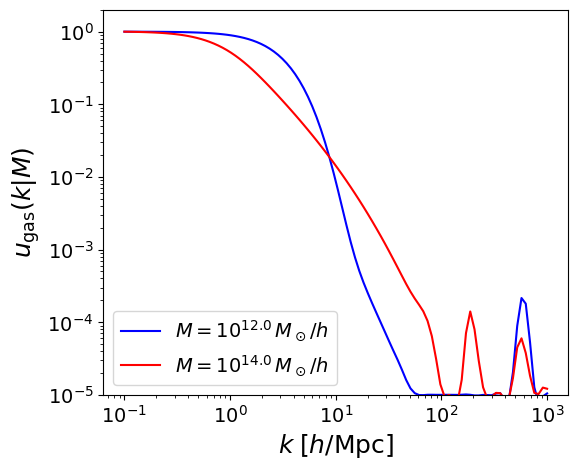

In [ ]:
k_grid = np.geomspace(1e-1, 1e3, 100)

plt.figure(figsize=(6,5))
for M, color in zip([1e12, 1e14], ['blue', 'red']):
    plt.plot(
        k_grid, 
        gasprofile.fourier(cfg.cosmo, k_grid, M, cfg.z), 
        label=rf"$M = 10^{{{np.log10(M):.1f}}}\,M_\odot/h$",
        color = color
        )
    # plt.plot(
    #     k_grid, 
    #     gasprofile.fourier2(cfg.cosmo, k_grid, M, cfg.z), 
    #     label=rf"$M = 10^{{{np.log10(M):.1f}}}\,M_\odot/h$",
    #     color = color
    #     )
    r_vir = R_virSO(cfg).R_vir(cfg.cosmo, M, z)
    
plt.xscale("log")
plt.yscale("log")
plt.ylim(1e-5, 2)
plt.legend(loc="lower left")

plt.ylabel(r"$u_\mathrm{gas}(k|M)$")
plt.xlabel(r"$k \;[h/\mathrm{Mpc}]$")
plt.savefig("normalized_gas_profile_fourier_space_mass_comparison.pdf",
            bbox_inches="tight")

plt.show()


In [ ]:
# Here we try to compute the gas fraction that is within R_500c
# note that we know that at large R we have that the f_gas = Omega_b/Omega_M - f_star

# first we have to setup the total smooth profile:

# define model objects

def total_profile(r, M):
    smooth = dmprofile.real(cfg.cosmo, r, M, cfg.z)
    
    rmin, rmax = 1e-5, 10
    r_grid = np.geomspace(rmin, rmax, Nr + 1)
    
    central_galaxy = stellar_profile.real(cfg.cosmo, r, M, cfg.z)
    star_normalization = romb(r_grid*stellar_profile.real(cfg.cosmo, r_grid, M, cfg.z), np.log(r_grid[1]) - np.log(r_grid[0]))  
    central_galaxy /= star_normalization
    
    gas = gasprofile.real(cfg.cosmo, r, M, cfg.z)
    gas_normalization = romb(r_grid*gasprofile.real(cfg.cosmo, r_grid, M, cfg.z), np.log(r_grid[1]) - np.log(r_grid[0]))  
    gas /= gas_normalization
    
    baryon_fraction = cfg.cosmo.Ob(cfg.z)/cfg.cosmo.Om(cfg.z)
    star_fraction = shmr_central(cfg.cosmo,M,cfg.z)
    return (1-baryon_fraction)*smooth + star_fraction*central_galaxy + (baryon_fraction - star_fraction)*gas


128
r_vir: 0.03503647156014282
r_vir: 0.1626248951627506
r_vir: 0.754837897454872


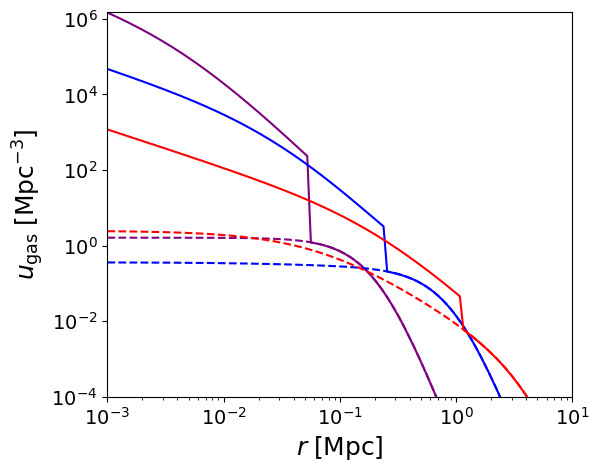

In [ ]:
cfg.massdef = "200c"

z = 0
rmin, rmax = 1e-3, 10
Nr = 2**7
print(Nr)
r_grid = np.geomspace(rmin, rmax, Nr + 1)

plt.figure(figsize=(6,5))
for M, color in zip([1e10, 1e12, 1e14], ['purple', 'blue', 'red']):
    r_vir = R_virSO(cfg).R_vir(cfg.cosmo, M, z)
    print("r_vir:", r_vir)

    rho_grid = total_profile(r_grid, M)
    plt.plot(
        r_grid,
        rho_grid,
        label=rf"total $M = 10^{{{np.log10(M):.1f}}}\,M_\odot/h$",
        color = color,
    )
    
    baryon_fraction = cfg.cosmo.Ob(cfg.z)/cfg.cosmo.Om(cfg.z)
    star_fraction = shmr_central(cfg.cosmo,M,cfg.z)
    
    rho_gas_grid = gasprofile.real(cfg.cosmo, r_grid, M, z)
    normalization = romb(r_grid*rho_gas_grid, np.log(r_grid[1]) - np.log(r_grid[0]))    
    rho_gas_grid = (baryon_fraction - star_fraction)*rho_gas_grid/normalization
    plt.plot(
        r_grid,
        rho_gas_grid,
        label=rf"gas $M = 10^{{{np.log10(M):.1f}}}\,M_\odot/h$",
        color = color,
        linestyle='--'
    )
    r_core = 0.1*r_vir
    r_eject = 6*r_vir

plt.xscale("log")
plt.xlim(rmin, rmax)
plt.ylim(1e-4, None)
plt.yscale("log")
plt.ylabel(r"$u_\mathrm{gas} \; [\mathrm{Mpc}^{-3}]$")
plt.xlabel(r"$r  \; [\mathrm{Mpc}]$")
# plt.legend(loc="lower left")
plt.savefig("normalized_gas_profile_real_space_mass_comparison.pdf",
            bbox_inches="tight")
plt.show()

In [ ]:
def f_gas(M, r, theta_ej):
    cfg_local = copy.deepcopy(cfg)
    cfg_local.theta_ej = theta_ej
    gas = ProfileGasCoredPowerLaw(cfg_local, shmr, c)
    
    R500 = R500c(cfg_local.cosmo, M, cfg_local.z)
    
    smooth = dmprofile.real(cfg.cosmo, R500, M, cfg.z)
        
    rmin, rmax = 1e-5, 10
    r_grid = np.geomspace(rmin, rmax, Nr + 1)
    
    central_galaxy = stellar_profile.real(cfg.cosmo, R500, M, cfg.z)
    star_normalization = romb(r_grid*stellar_profile.real(cfg.cosmo, r_grid, M, cfg.z), np.log(r_grid[1]) - np.log(r_grid[0]))  
    central_galaxy /= star_normalization
    
    gas = gasprofile.real(cfg.cosmo, R500, M, cfg.z)
    gas_normalization = romb(r_grid*gasprofile.real(cfg.cosmo, r_grid, M, cfg.z), np.log(r_grid[1]) - np.log(r_grid[0]))  
    gas /= gas_normalization
    
    baryon_fraction = cfg.cosmo.Ob(cfg.z)/cfg.cosmo.Om(cfg.z)
    star_fraction = shmr_central(cfg.cosmo,M,cfg.z)
    
    return (baryon_fraction - star_fraction)*gas / ((1-baryon_fraction)*smooth + star_fraction*central_galaxy + (baryon_fraction - star_fraction)*gas)
    

